# Squeezing in step-index fiber

This example illustrates squeezing by spectral filtering for an LP01 launch in step-index fiber. This notebook illustrates the forward solve, adjoint, and CP compression aspects of the code.

In [ ]:
using Pkg

ROOT = abspath(joinpath(@__DIR__, ".."))
Pkg.activate(ROOT)

using PulsePropagation
using FFTW
using LinearAlgebra
using PyPlot
using Statistics

  Activating project at `~/FastDifferentiableMMNLO`


A typical flow is shown below. We start by establishing what the degrees of freedom are and setup a time-grid. We also compute the frequency and wavelength grids, which are useful to have.

In [ ]:
c_light = 2.99792458e-4; # m/ps -- see manual for unit system info
Nt = 2^11;
time_window = 10; # ps
λ0 = 1379.2e-9; # m
ω0 = 2*π*c_light/λ0;

time_grid = TimeGrid(Nt,time_window);
t = time_axis(time_grid);
Ω = frequency_axis(time_grid); # constructs relative frequency
ω = ω0 .+ Ω; # absolute frequency;
λ = wavelength_axis(time_grid,ω0); # wavelength

dofs = degrees_of_freedom(:time, :space)
domain = MMGNLSEDomain(dofs, time_grid);


Now, we need to setup the dispersion and nonlinearity which determine our dynamics. This is done below by establishing the material and fiber system and computing derived properties.

In [ ]:
core_radius = 52.5e-6;
NA = 0.1;
num_modes = 3;
fiber_length = 2.86;

material = Silica() # The default Silica picks an anisotropic Raman model. See other notebooks such as soliton_jitter for other Raman models;
step_fiber = StepIndex(λ0, core_radius, NA);

properties = compute_fiber_properties(step_fiber, material, num_modes, polarization=:scalar, mode_basis=:LP, beta_order=5)

Some examples of how you can get property values from properties.

In [ ]:
x = y = properties.modes.x
modes = properties.modes.fields; 
betas = properties.beta.coefficients;
S_tensor = properties.S.values;

Taking a peek at the first 3 step-index mode fields.

In [ ]:
figure(figsize=(18,6))

for ii = 1:3
    subplot(1,3,ii)
    pcolormesh(x*1e6,y*1e6,modes[:,:,ii],cmap="seismic")
end
display(gcf())

We are ready to setup a forward solve. First we set up initial conditions.

In [6]:
peak_power = 100000;
pulse_fwhm = 0.2;

# pulse_tau = pulse_fwhm / (2*acosh(sqrt(2)));
# initial_field = zeros(Nt,num_modes,1);
# initial_field[:,1,1] .= sqrt(peak_power)*sech.(t/pulse_tau);

coefficient_vector = zeros(num_modes);
coefficient_vector[1] = 1.0;

initial_field = gaussian_pulse(
    domain, num_modes;
    peak_power=peak_power, # W
    fwhm=pulse_fwhm,
    coefficients = coefficient_vector
);

The code require us to collect all parameters as follows

In [7]:
parameters = MMGNLSEParameters(domain;
length=fiber_length,
beta=properties.beta,
S=properties.S,
n2=properties.n2,
omega0=properties.omega0,
raman=properties.raman)

MMGNLSEParameters{MMGNLSEDomain{TimeGrid{Float64}}, Float64, Array{Int64, 4}, Array{Int64, 4}, TaylorBeta{Float64, 2}, SpatialOverlap{Float64}, Float64, Float64, AnisotropicRaman{Float64}}(MMGNLSEDomain{TimeGrid{Float64}}(DegreesOfFreedom(:time, :space), TimeGrid{Float64}(2048, 0.0048828125)), 2.86, [0;;;;], [0;;;;], TaylorBeta{Float64, 2}([6.58743778344516e6 6.58721209206506e6 6.58721209206506e6; 4876.066183290184 4876.219784144979 4876.219784144979; … ; -2.557747949166768e-7 -2.569478135168283e-7 -2.569478135168283e-7; 1.0507874940407848e-9 1.0537998629535228e-9 1.0537998629535228e-9]), SpatialOverlap{Float64}([2.231855540561089e8 1.569614947959047e-8 -6.849108156409251e-10; 1.569614947959047e-8 1.5260056571180487e8 -6.503391465454317e-10; -6.849108156409251e-10 -6.503391465454317e-10 1.5260056571180496e8;;; 1.569614947959047e-8 1.526005657118049e8 -4.3514518391196353e-10; 1.5260056571180487e8 -2.1167456645574383e-8 4.850236927018675e-10; -6.503391465454317e-10 4.23442849130913e-10 -

Now we can solve.

In [32]:
dz = fiber_length/4000;
solution = solve_mmgnlse(initial_field, parameters, dz; saveat=0.1);

Visualizing the solution.

In [33]:
At_final = get_temporal_field(solution)
Aomega_final = get_spectral_field(solution)
z_saved = solution.z;

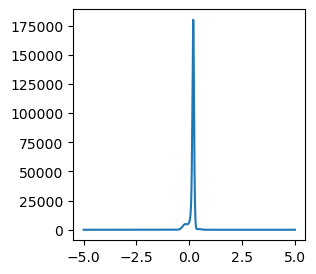

In [34]:
figure(figsize=(3,3))
plot(t,abs2.(At_final[:,1,1]))
display(gcf())

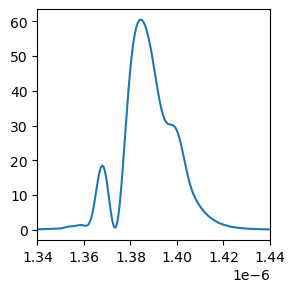

In [35]:
figure(figsize=(3,3))
plot(λ,abs2.(Aomega_final[:,1,1]))
xlim(1340e-9,1440e-9)
display(gcf())

## CP Decomposition

Let us now show that by compressing the four-wave mixing tensor in advance of the calculation, it can be sped up significantly. The added work to do this amounts to compressing the S-tensor and recreating the parameters to incorporate the compressed tensor.

In [36]:
S_compressed = cp_compress(properties.S,error=1e-3);

In [37]:
parameters_cp = MMGNLSEParameters(domain;
length=fiber_length,
beta=properties.beta,
S=S_compressed,
n2=properties.n2,
omega0=properties.omega0,
raman=properties.raman)

dz = 1e-3;

solution_cp = solve_mmgnlse(initial_field, parameters_cp, dz; saveat=0.1);

In [38]:
At_final_cp = get_temporal_field(solution_cp)
Aomega_final_cp = get_spectral_field(solution_cp)
z_saved_cp = solution_cp.z;

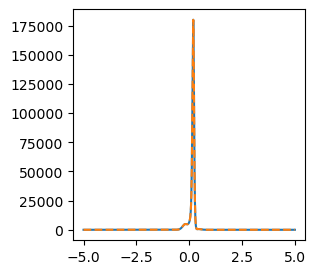

In [39]:
figure(figsize=(3,3))
plot(t,abs2.(At_final[:,1,1]))
plot(t,abs2.(At_final_cp[:,1,1]),"--")
display(gcf())

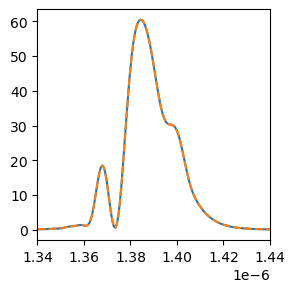

In [40]:
figure(figsize=(3,3))
plot(λ,abs2.(Aomega_final[:,1,1]))
plot(λ,abs2.(Aomega_final_cp[:,1,1]),"--")
xlim(1340e-9,1440e-9)
display(gcf())

At six modes, there is a speedup of around 10x. Now we look at the adjoint.

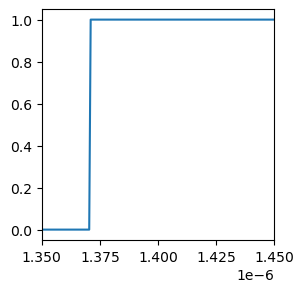

In [41]:
long_pass_ind = argmin(abs.(λ .-  1370.6998e-9))
filter = zeros(length(λ));
filter[1:long_pass_ind] .= 1.0;

figure(figsize=(3,3))
plot(λ, filter)
xlim(1350e-9,1450e-9)
display(gcf())

In [42]:
longpass_photon_number =  SpectralPhotonNumber(filter=filter, modes=:all);
filter_mean = value(longpass_photon_number, solution_cp)
lambda_L = terminal_condition(longpass_photon_number, solution_cp);

In [43]:
dz_adj = fiber_length/4000;

adjoint = solve_adjoint(lambda_L, parameters_cp, dz_adj; forward_solution=solution_cp)

MMGNLSEAdjointSolution{Float64, Array{ComplexF64, 4}, MMGNLSEParameters{MMGNLSEDomain{TimeGrid{Float64}}, Float64, Array{Int64, 4}, Array{Int64, 4}, TaylorBeta{Float64, 2}, MMGNLSECPDecomposition{Float64, ComplexF64}, Float64, Float64, AnisotropicRaman{Float64}}, @NamedTuple{forward_solution::MMGNLSESolution{Float64, Array{ComplexF64, 4}, MMGNLSEParameters{MMGNLSEDomain{TimeGrid{Float64}}, Float64, Array{Int64, 4}, Array{Int64, 4}, TaylorBeta{Float64, 2}, MMGNLSECPDecomposition{Float64, ComplexF64}, Float64, Float64, AnisotropicRaman{Float64}}, Array{ComplexF64, 3}, RK4IP, @NamedTuple{integration_z::Vector{Float64}, core::@NamedTuple{omega::Vector{Float64}, beta_operator::Array{ComplexF64, 3}, nonlinear_prefactor::Array{ComplexF64, 3}, nonlinear_active::Bool, raman::@NamedTuple{ha::Vector{ComplexF64}, hb::Vector{ComplexF64}, fraction::Float64}}}}, integration_z::Vector{Float64}, frame::Symbol, core::@NamedTuple{omega::Vector{Float64}, beta_operator::Array{ComplexF64, 3}, nonlinear_pref

In [44]:
filter_var = sum(abs2.(get_spectral_field(adjoint; units=:photon)[:,:,1]));

In [45]:
fano = filter_var / filter_mean
10log10(fano)

-7.679183368141689

We can check the adjoint against automatic differentiation: the agreement is very strong even for a coarse dz_ad (automatic differentiation is very memory intensive.)

In [46]:
dz_ad = 1e-2;
adjoint_ad = get_autodiff_adjoint(
    longpass_photon_number,
    initial_field,
    parameters_cp,
    dz_ad; units=:photon
)

2048×3×1 Array{ComplexF64, 3}:
[:, :, 1] =
 -7.56059e-12+8.44736e-12im  …   1.88436e-13-2.84209e-14im
  1.46239e-11+2.01058e-12im      6.25861e-14-3.29528e-14im
 -2.56748e-12-1.65147e-11im     -2.74669e-13+3.49882e-14im
  7.37911e-12+1.3778e-11im      -1.80562e-13-1.62929e-13im
   1.0437e-11-1.83283e-11im      4.77229e-14+3.1308e-14im
 -4.02027e-12+3.98884e-12im  …  -8.66609e-14+7.57432e-14im
   6.8299e-12+1.24693e-11im       1.6073e-13-1.97215e-14im
  1.74151e-11+8.28724e-13im     -1.26792e-13+8.56469e-14im
  8.30399e-13-2.49588e-11im      -4.8657e-13+5.8583e-14im
 -1.60128e-11+4.87982e-12im      2.47194e-14-3.15365e-14im
             ⋮               ⋱  
 -2.29451e-11+2.24771e-11im      1.31748e-13-3.56805e-13im
  1.65049e-11+1.24613e-11im  …   4.61796e-13-4.17736e-13im
  2.42389e-12-4.42065e-11im       3.0382e-13-5.71345e-14im
 -2.73626e-11+1.73956e-11im     -2.01964e-13-3.30595e-14im
   2.7922e-11+2.556e-11im        8.70255e-14+7.47238e-14im
   2.0085e-11-9.23801e-12im     -1.87719e

In [47]:
filter_var_ad = sum(abs2.(adjoint_ad))
fano_ad = 10log10.(filter_var_ad/filter_mean);

Let's benchmark this result against a stochastic (truncated Wigner) calculation. Without any key word arguments, a seed is set and the input noise is vacuum fluctuations in each mode (frequency-mode-polarization). See manual for details. 

In [48]:
num_ensemble = 100;
ensemble = solve_mmgnlse_stochastic(initial_field, parameters_cp, dz, num_ensemble)

MMGNLSEStochasticSolution{Float64, Array{ComplexF64, 5}, MMGNLSEParameters{MMGNLSEDomain{TimeGrid{Float64}}, Float64, Array{Int64, 4}, Array{Int64, 4}, TaylorBeta{Float64, 2}, MMGNLSECPDecomposition{Float64, ComplexF64}, Float64, Float64, AnisotropicRaman{Float64}}, @NamedTuple{fano::Array{Float64, 3}, photon_noise::Array{ComplexF64, 4}, weights::Vector{Float64}, seed::Nothing}}([0.0, 2.86], ComplexF64[-0.002384608201197125 - 0.0032462541232764286im 0.0013361439460041426 - 0.001588276680670141im 0.0031517255461900656 - 0.0007139025941868813im; -0.0010761030259516247 - 0.003219648651701877im 0.0010255154225417224 - 0.001598207694404023im -0.004093850272254492 - 0.004533899151470556im; … ; -0.0005237776072704037 + 5.942743941858282e-5im 0.0047780505493548765 + 0.003962005791195098im -0.003394861918527542 - 0.0012781261667740643im; 0.004048589807737812 - 0.00038533381669985474im -0.0012869220171150366 - 0.0013507644080117246im 0.0016729923140733896 - 0.00025815271529551834im;;;; -0.000910

In [50]:
fano_stochastic = 10log10(var(value(longpass_photon_number, ensemble)) / filter_mean)

-8.46745308952325